# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

# Data Problem
The objective of this project is to identify the main vehicle features that drive the price of a used vehicle.

Translating this as a data problem, we are aiming to build a **supervised regression model** that predicts the **target variable** price of a used vehicle given the **input features**, which are the vehicle characteristics  including year, manufacturer, model, transmission, gas type to name a few.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data/vehicles.csv')
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

The way I would look to understand the data would be taking the steps as follows:


1.   Examine DataFrame to understand column names, data types and overall shape.
2.   Understand where data is missing in the dataframe.
3.   Visualize key variable distribtutions.
4.   Identify any outliers and issues with overall data quality.
5.   Begin to explore feature relationships with respect to the target variable.





In [ ]:
#=========================================
# List Columns to see title uniformity
# as well as what type of data to expect.
#=========================================
df.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [ ]:
#====================================
# Load Data into DataFrame and Look
# at the shape it currently holds.
#====================================
df.shape

(426880, 18)

In [ ]:
#=====================================
# Understanding Data Types for Columns
# and Entry counts
#=====================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [ ]:
#====================================
# Look at the First 10 Entries
#====================================]
df.head(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


In [ ]:
#====================================
# Look at the Last 10 Entries
#====================================
df.tail(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426870,7301592119,wyoming,22990,2020.0,hyundai,sonata se sedan 4d,good,NaN,gas,3066.0,clean,other,5NPEG4JAXLH051710,fwd,NaN,sedan,blue,wy
426871,7301591639,wyoming,17990,2018.0,kia,sportage lx sport utility 4d,good,NaN,gas,34239.0,clean,other,KNDPMCAC7J7417329,NaN,NaN,SUV,NaN,wy
426872,7301591201,wyoming,32590,2020.0,mercedes-benz,c-class c 300,good,NaN,gas,19059.0,clean,other,55SWF8DB6LU325050,rwd,NaN,sedan,white,wy
426873,7301591202,wyoming,30990,2018.0,mercedes-benz,glc 300 sport,good,NaN,gas,15080.0,clean,automatic,WDC0G4JB6JV019749,rwd,NaN,other,white,wy
426874,7301591199,wyoming,33590,2018.0,lexus,gs 350 sedan 4d,good,6 cylinders,gas,30814.0,clean,automatic,JTHBZ1BLXJA012999,rwd,NaN,sedan,white,wy
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [ ]:
#====================================
# Understand Missing Data for
# Columns in the Data Set
#====================================
missing_data = []
for col in df.columns:
    missing_data.append(df[col].isna().sum() / df.shape[0] * 100)
totals = pd.DataFrame({'col': df.columns, 'missing_data_percentage': missing_data})
totals.sort_values(by='missing_data_percentage', ascending=False)

,col,missing_data_percentage
14,size,71.767476
7,cylinders,41.622470
6,condition,40.785232
12,VIN,37.725356
13,drive,30.586347
16,paint_color,30.501078
15,type,21.752717
4,manufacturer,4.133714
10,title_status,1.930753
5,model,1.236179


In [ ]:
#====================================
# Value Counts of Entries
# in Data Frame.
#====================================
unique_entries = []
unique_percentage = []
for col in df.columns:
    unique_entries.append(df[col].nunique())
    unique_percentage.append(df[col].nunique() / df.shape[0] * 100)
totals = pd.DataFrame({'col': df.columns, 'unique_data_entries': unique_entries, 'percentage_unique': unique_percentage})
totals.sort_values(by='unique_data_entries', ascending=False)

,col,unique_data_entries,percentage_unique
0,id,426880,100.000000
12,VIN,118246,27.700056
9,odometer,104870,24.566623
5,model,29649,6.945512
2,price,15655,3.667307
1,region,404,0.094640
3,year,114,0.026705
17,state,51,0.011947
4,manufacturer,42,0.009839
15,type,13,0.003045


In [ ]:
#=====================================
# Look at some statistics of the
# numerical data.
#=====================================
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [ ]:
#====================================
# Look at the Ranges for year,
# odometer, price.
#====================================
for col in df.describe():
    print(f'{col}: {df[col].min()} - {df[col].max()}')

id: 7207408119 - 7317101084
price: 0 - 3736928711
year: 1900.0 - 2022.0
odometer: 0.0 - 10000000.0


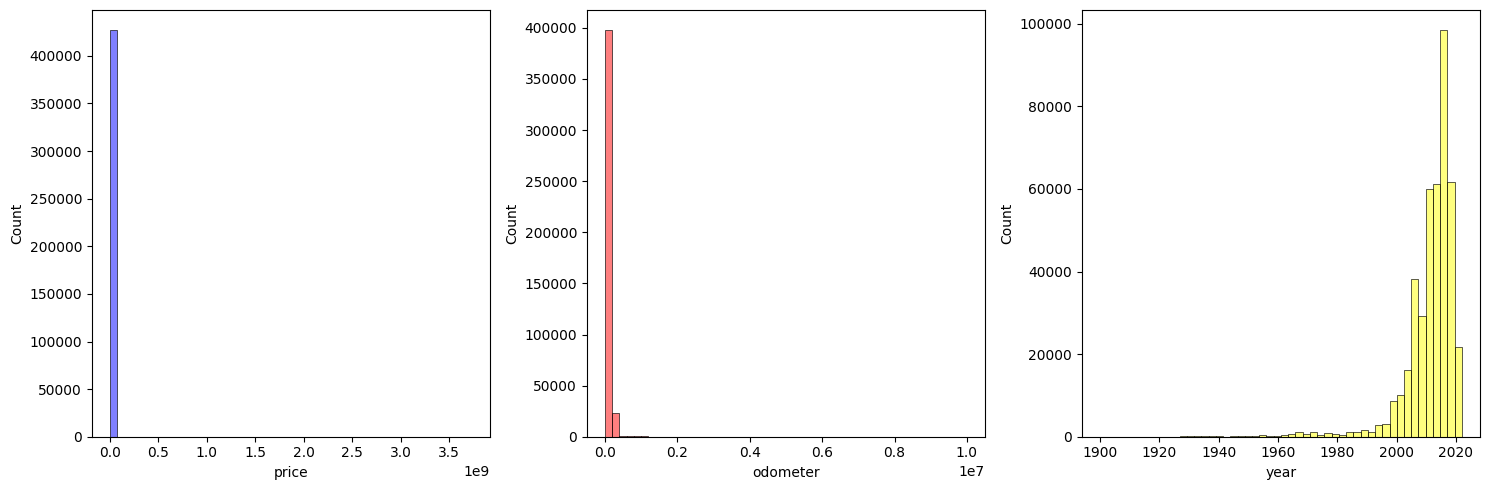

In [ ]:
#====================================
# Visualize Numerical Data
#====================================
fig, ax = plt.subplots(1,3,figsize=(15,5))
sns.histplot(df['price'], bins = 50, alpha= 0.5, color = 'blue', ax = ax[0])
sns.histplot(df['odometer'], bins = 50, alpha= 0.5, color = 'red', ax=ax[1])
sns.histplot(df['year'], bins = 50, alpha= 0.5, color = 'yellow', ax=ax[2])
plt.tight_layout()
plt.show()


After looking doing some intial audits on the data that is provided, we see some areas of concern. Below are a few highlights that I would like to prioritize for cleaning the data set overall.   


---
1.   Plenty of missing data, Size alone missing 71% --> Drop worthy column.
2.   The model column can be problematic with a ~7% unique value percentage. Too many unique string entries is difficult to work with.   
3. The price range is very wide and unrealistic for normal used car prices, will need to limit the price range included in the model.
4. Year shows us that the data is very modern year heavy, will choose years where majority of data can be found. 25 years or newer seems to be ideal from illustration above.
5. Certain columns do not provide value for the model, such as identifier columns including the ID, VIN, State, Region columns. Ultimately worth dropping for the model.



### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
#====================================
# Make a copy of the dataframe for
# prepping data.
#====================================
clean_df = df.copy()
print(f'DataFrames are the same instances: {clean_df is df}')
clean_df

DataFrames are the same instances: False


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy


In [ ]:
#=========================================
# Remove columns that are identifiers,
# too unique, or missing too much data.
#=========================================
cols_to_drop = ['id','VIN','region','state','model', 'size']
size_before = clean_df.shape
clean_df = clean_df.drop(columns=cols_to_drop)
size_after = clean_df.shape
print(f'DataFrame size before dropping columns: {size_before}')
print(f'DataFrame size after dropping columns: {size_after}')

DataFrame size before dropping columns: (426880, 18)
DataFrame size after dropping columns: (426880, 12)


In [ ]:
#=========================================
# Establish realistic ranges for entries.
# Price, year, odometer specifically.
#=========================================
print(f'Original DataFrame size: {len(df)}')
clean_df = clean_df[(clean_df['price']>= 1000) & (clean_df['price']<= 100000)]
after_price = len(clean_df)
print(f'DataFrame size after price filter (price range from 1000 - 100,000): {after_price}')

clean_df = clean_df[(clean_df['year']>= 1992) & (clean_df['year']<= 2022)]
after_year = len(clean_df)
print(f'DataFrame size after year filter (Cars 25 years or newer): {after_year}')

clean_df = clean_df[(clean_df['odometer'] > 0) & (clean_df['odometer'] < 300000)]
after_odometer = len(clean_df)
print(f'DataFrame size after odometer filter(Under 300,000 miles): {after_odometer}')

Original DataFrame size: 426880
DataFrame size after price filter (price range from 1000 - 100,000): 379910
DataFrame size after year filter (Cars 25 years or newer): 365964
DataFrame size after odometer filter(Under 300,000 miles): 360780


In [ ]:
#====================================
# Understand Missing Values in
# remaining data.
#====================================
print(clean_df.isnull().sum().sort_values(ascending=False))

cylinders       148626
condition       136628
drive           108318
paint_color     101831
type             74025
manufacturer     10778
title_status      5871
fuel              2075
transmission      1494
year                 0
price                0
odometer             0
dtype: int64


In [ ]:
#====================================
# Drop entries with missing data.
#====================================
before_dropping = clean_df.shape
clean_df = clean_df.dropna(subset=['manufacturer','condition','cylinders','fuel','title_status','transmission','drive','type','paint_color'])
after_dropping = clean_df.shape
print(clean_df.isnull().sum().sort_values(ascending=False))

print(f'DataFrame size before dropping columns: {before_dropping}')
print(f'DataFrame size after dropping columns: {after_dropping}')

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
dtype: int64
DataFrame size before dropping columns: (360780, 12)
DataFrame size after dropping columns: (104765, 12)


In [ ]:
#====================================
# Add a vehicle age column on the
# remaining DF , new feature for the
# age of the vehicle.
#====================================
clean_df['vehicle_age'] = 2022 - clean_df['year']
clean_df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,vehicle_age
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,9.0
32,27990,2012.0,gmc,good,8 cylinders,gas,68696.0,clean,other,4wd,pickup,black,10.0
33,34590,2016.0,chevrolet,good,6 cylinders,gas,29499.0,clean,other,4wd,pickup,silver,6.0
34,35000,2019.0,toyota,excellent,6 cylinders,gas,43000.0,clean,automatic,4wd,truck,grey,3.0
35,29990,2016.0,chevrolet,good,6 cylinders,gas,17302.0,clean,other,4wd,pickup,red,6.0


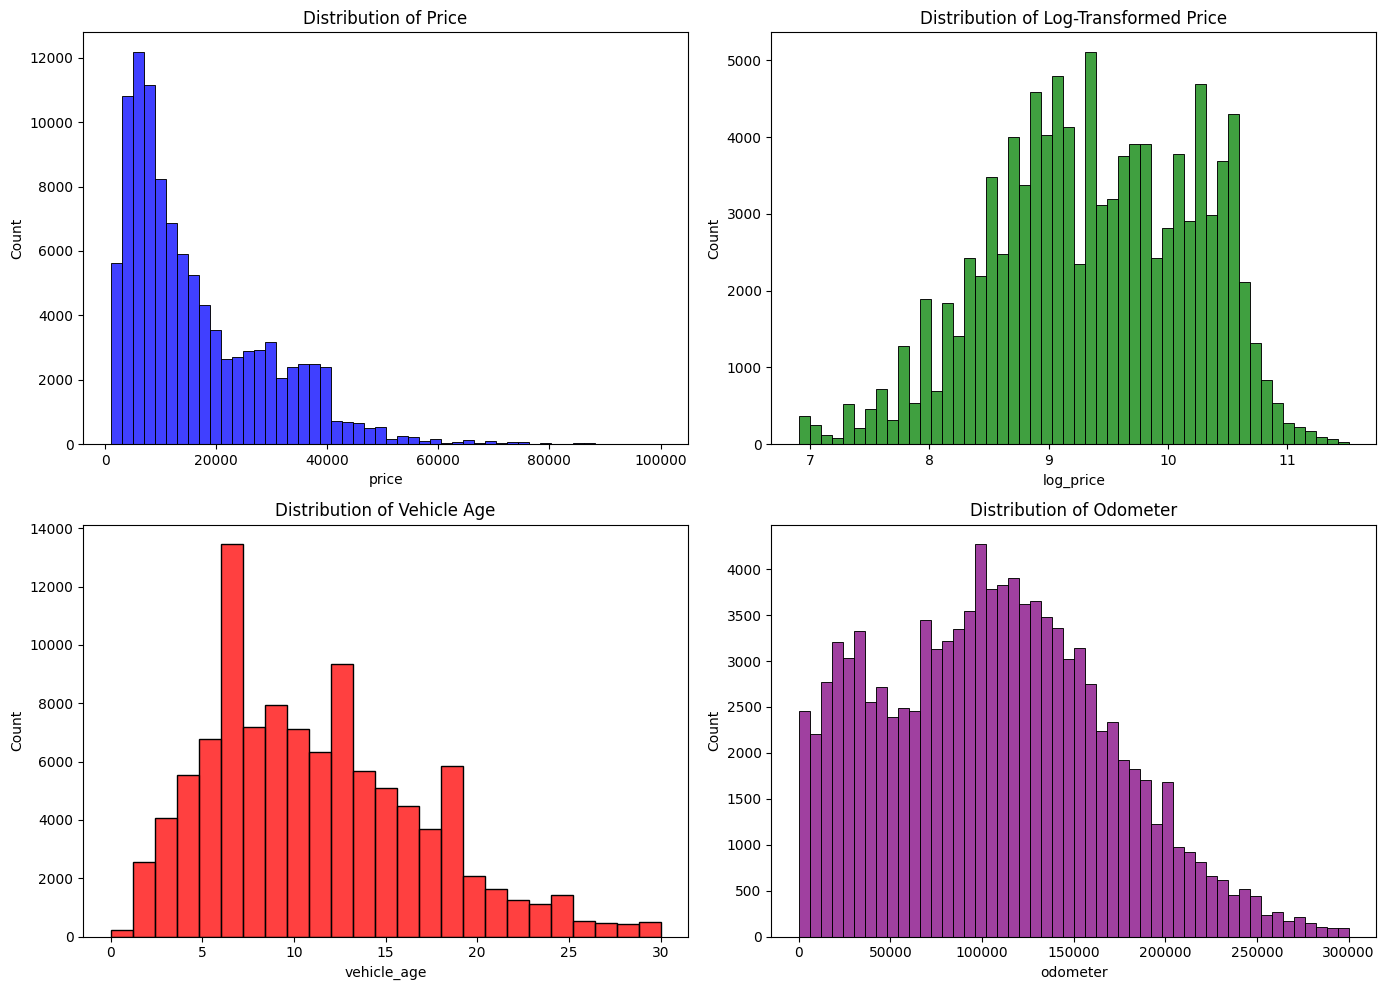

In [ ]:
#============================================
# Visualize the distributions of price,
# log of price for visualization, vehicle age,
# and odometer after cleaning the Data.
#=============================================
clean_df['log_price'] = np.log(clean_df['price'])

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
sns.histplot(clean_df['price'], bins=50, ax=ax[0, 0], color='blue')
ax[0, 0].set_title('Distribution of Price')
sns.histplot(clean_df['log_price'], bins=50, ax=ax[0, 1], color='green')
ax[0, 1].set_title('Distribution of Log-Transformed Price')
sns.histplot(clean_df['vehicle_age'], bins=25, ax=ax[1, 0], color='red')
ax[1, 0].set_title('Distribution of Vehicle Age')
sns.histplot(clean_df['odometer'], bins=50, ax=ax[1, 1], color='purple')
ax[1, 1].set_title('Distribution of Odometer')
plt.tight_layout()
plt.show()

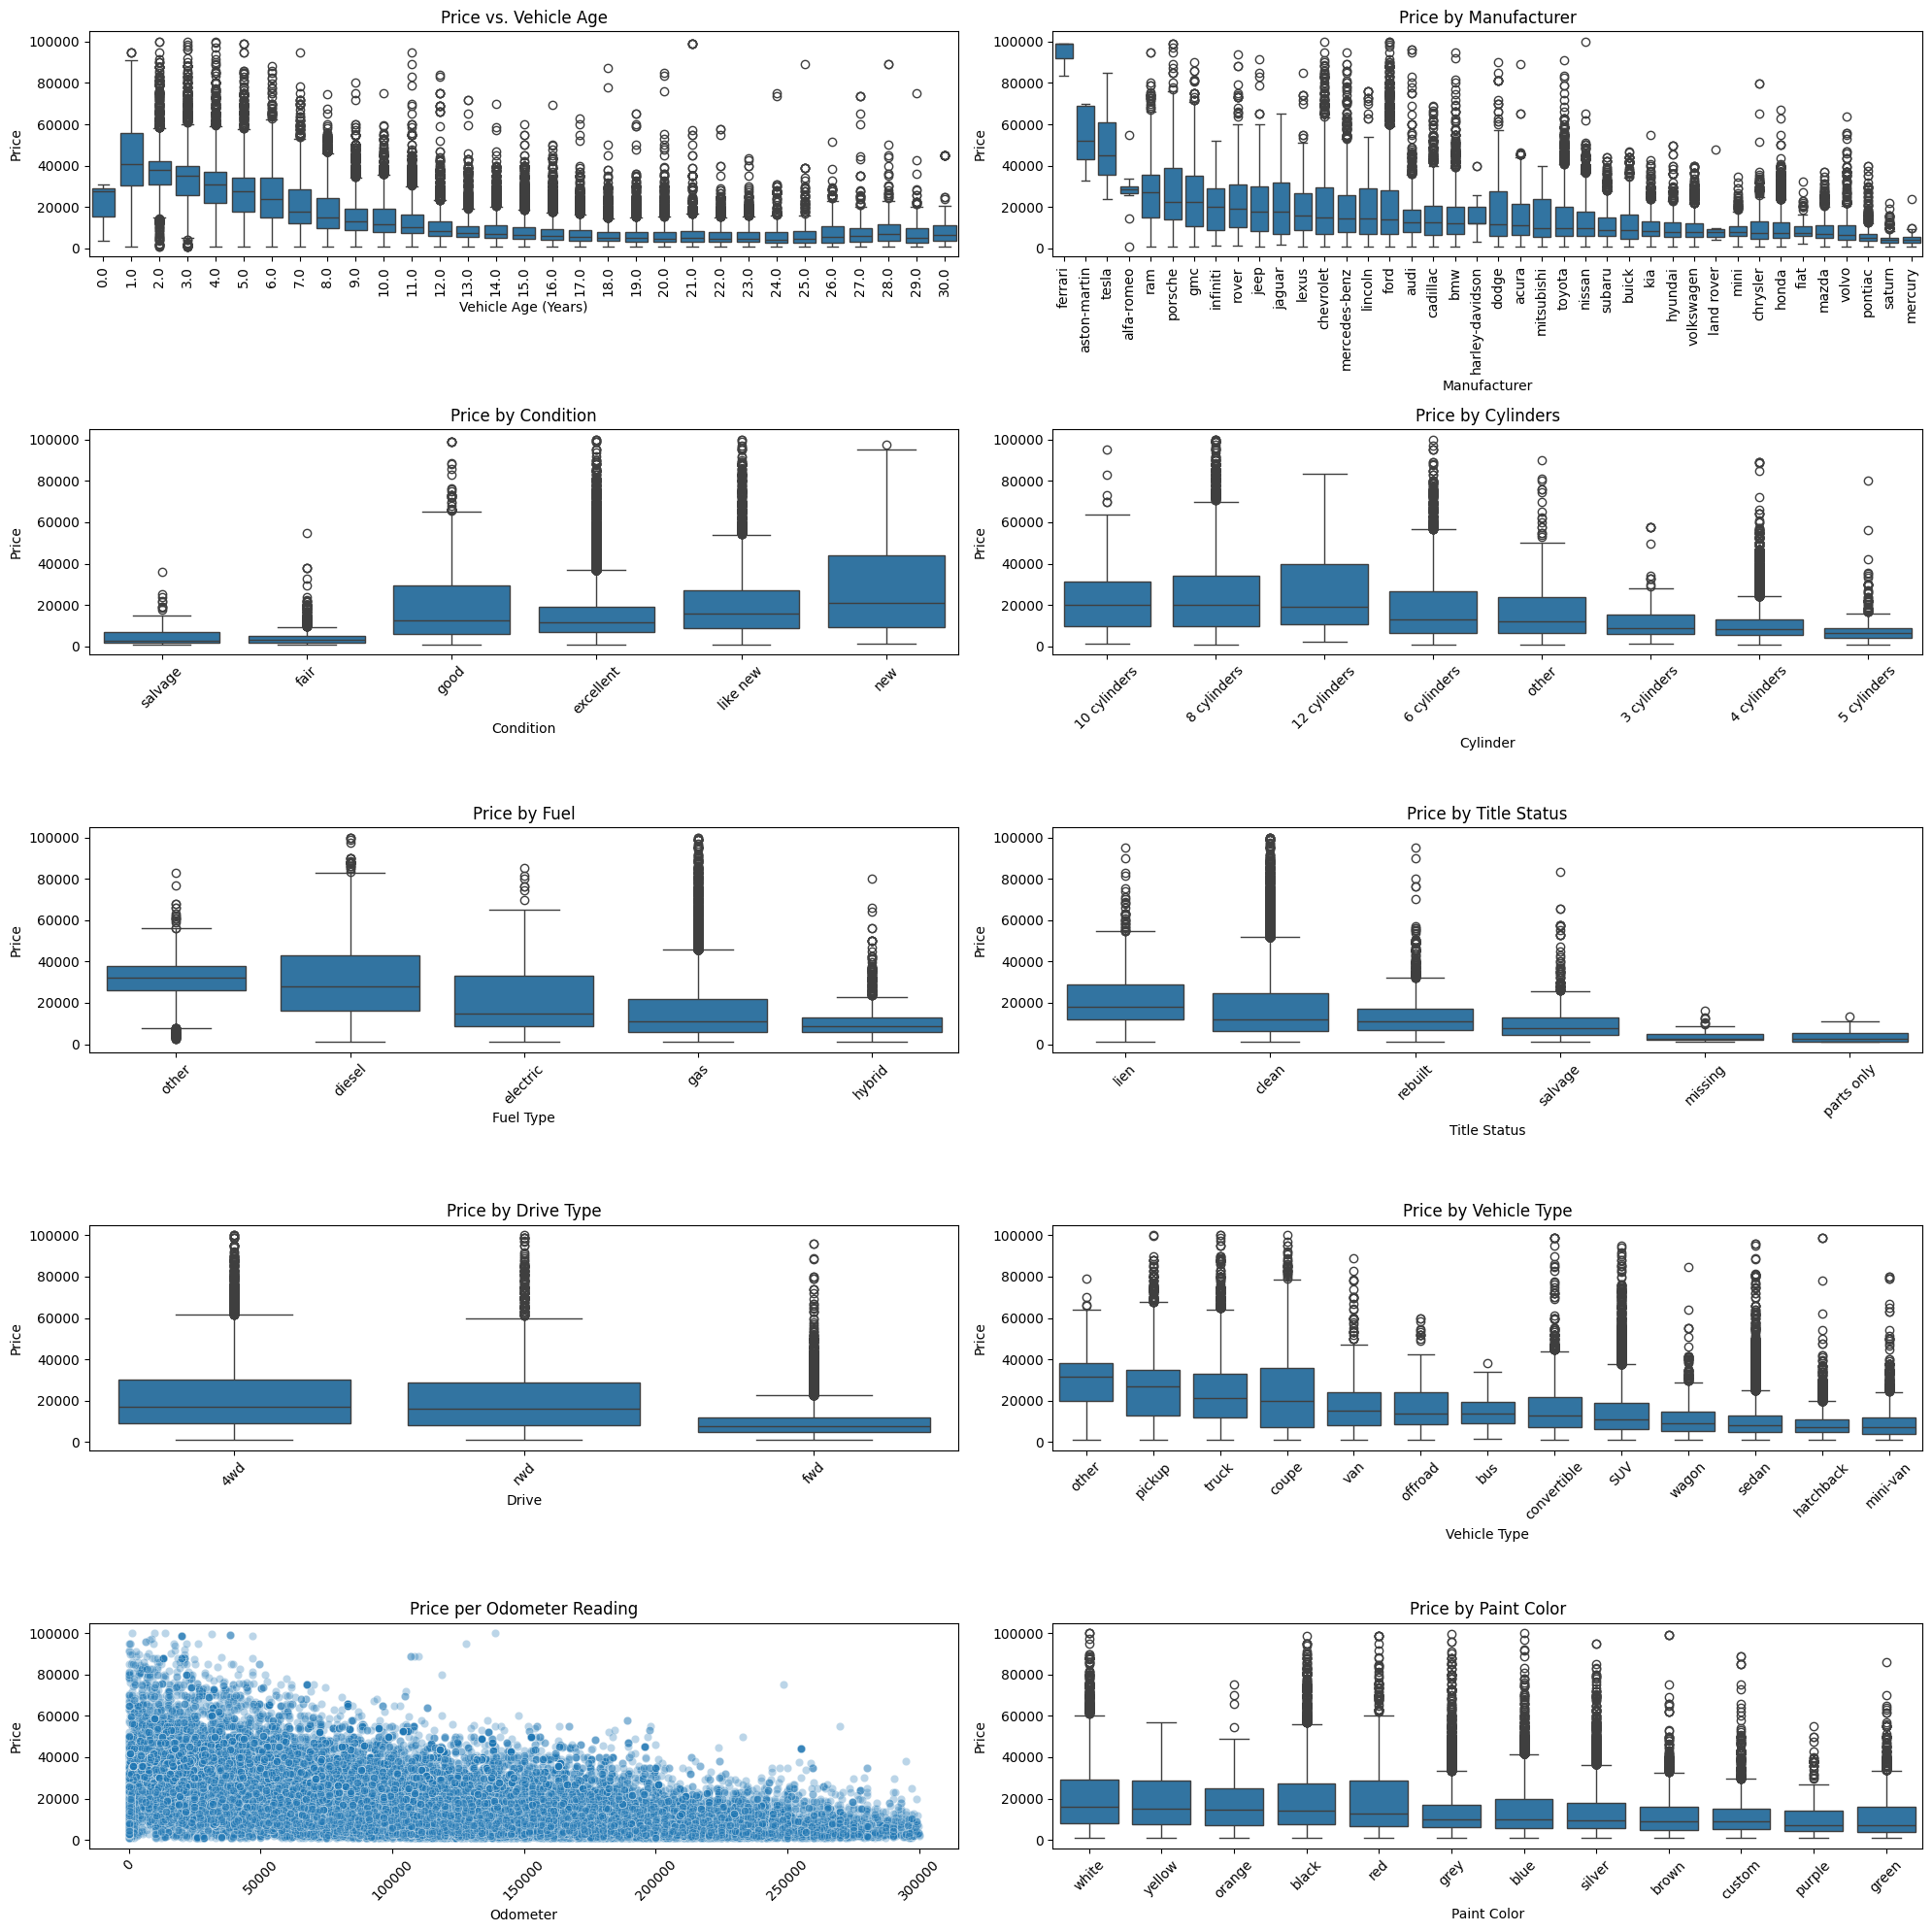

In [ ]:
#=================================================================
# Visualize the relationships of price with all characteristics.
# Focus on all different features present in the Dataframe.
#=================================================================
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))


#Price by Vehicle Age
sns.boxplot(x='vehicle_age', y='price', data=clean_df, ax = ax[0,0])
ax[0,0].set_title('Price vs. Vehicle Age')
ax[0,0].set_xlabel('Vehicle Age (Years)')
ax[0,0].set_ylabel('Price')
ax[0,0].tick_params(rotation=90, axis = 'x')

#Price by Manufacturer
manufacturer_order = clean_df.groupby('manufacturer')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='manufacturer', y='price', data=clean_df, order = manufacturer_order, ax = ax[0,1])
ax[0,1].set_title('Price by Manufacturer')
ax[0,1].set_xlabel('Manufacturer')
ax[0,1].set_ylabel('Price')
ax[0,1].tick_params(rotation=90, axis = 'x')

#Price by Condition
condition_order = ['salvage','fair','good','excellent','like new','new']
sns.boxplot(x='condition', y='price', data=clean_df, order = condition_order, ax = ax[1,0])
ax[1,0].set_title('Price by Condition')
ax[1,0].set_xlabel('Condition')
ax[1,0].set_ylabel('Price')
ax[1,0].tick_params(rotation=45, axis = 'x')

#Price by Cylinders
cylinder_order = clean_df.groupby('cylinders')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='cylinders', y='price', data=clean_df, order = cylinder_order, ax = ax[1,1])
ax[1,1].set_title('Price by Cylinders')
ax[1,1].set_xlabel('Cylinder')
ax[1,1].set_ylabel('Price')
ax[1,1].tick_params(rotation=45, axis = 'x')

#Price by Fuel
fuel_order = clean_df.groupby('fuel')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='fuel', y='price', data=clean_df, order = fuel_order, ax = ax[2,0])
ax[2,0].set_title('Price by Fuel')
ax[2,0].set_xlabel('Fuel Type')
ax[2,0].set_ylabel('Price')
ax[2,0].tick_params(rotation=45, axis = 'x')

#Price by Title Status
title_order = clean_df.groupby('title_status')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='title_status', y='price', data=clean_df, order = title_order, ax = ax[2,1])
ax[2,1].set_title('Price by Title Status')
ax[2,1].set_xlabel('Title Status')
ax[2,1].set_ylabel('Price')
ax[2,1].tick_params(rotation=45, axis = 'x')

#Price by Drive Type
drive_order = clean_df.groupby('drive')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='drive', y='price', data=clean_df, order = drive_order, ax = ax[3,0])
ax[3,0].set_title('Price by Drive Type')
ax[3,0].set_xlabel('Drive')
ax[3,0].set_ylabel('Price')
ax[3,0].tick_params(rotation=45, axis = 'x')

#Price by Vehicle Type
type_order = clean_df.groupby('type')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='type', y='price', data=clean_df, order = type_order, ax = ax[3,1])
ax[3,1].set_title('Price by Vehicle Type')
ax[3,1].set_xlabel('Vehicle Type')
ax[3,1].set_ylabel('Price')
ax[3,1].tick_params(rotation=45, axis = 'x')

#Price by Odometer
sns.scatterplot(x='odometer', y='price', data=clean_df, alpha = 0.3 , ax = ax[4,0])
ax[4,0].set_title('Price per Odometer Reading')
ax[4,0].set_xlabel('Odometer')
ax[4,0].set_ylabel('Price')
ax[4,0].tick_params(rotation=45, axis = 'x')

#Price by Paint Color
paint_order = clean_df.groupby('paint_color')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='paint_color', y='price', data=clean_df, order = paint_order, ax = ax[4,1])
ax[4,1].set_title('Price by Paint Color')
ax[4,1].set_xlabel('Paint Color')
ax[4,1].set_ylabel('Price')
ax[4,1].tick_params(rotation=45, axis = 'x')
plt.tight_layout()
plt.show()

In [ ]:
#=================================================================
# With 40 Manufacturers in the Dataframe, select the ones with
# the most data to learn from to reduce dimensionality.
#=================================================================
manufacturer_count = clean_df['manufacturer'].value_counts()
manufacturer_data_percentage = clean_df['manufacturer'].value_counts(normalize=True) * 100
man_df = pd.DataFrame(
    {'manufacturer_count': manufacturer_count,
     'data_percentage': manufacturer_data_percentage})
man_df

,manufacturer_count,data_percentage
manufacturer,,
ford,18537,17.693886
chevrolet,15306,14.609841
toyota,9250,8.829285
honda,6289,6.002959
nissan,5793,5.529518
jeep,5153,4.918627
gmc,4446,4.243784
ram,3902,3.724526
dodge,3722,3.552713


Cleaning the data has allowed us to keep only the most usable data for our model. While other techniques towards handeling missing data exist, I ulitmately opted to simply drop the entries with missing data due to the high variability in vehicle features and pricing that is exhibited in the world.  

We will also need to be selective of the manufacturers we use for our models to reduce overall dimensionality. I will be implementing a threshold of manufacturers that have atleast 1% of data available, which will include 24 of the possible 40 manufacturers within the dataset.  

With the visualizaions of relationships between price and the features remaining in the dataframe, we can begin to obtain some insight on which features hold more weight towards the impact of pricing on used vehicles. The features with distinguishable trends from the depictions above include vehicle age, fuel, title status, condition and odometer. This correlates well with natural intuition regarding vehicle pricing in general. We will now look to build some models for comparison to find the one that best fits our data.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:
#=================================================================
# Reduce Dimensionality and select Manufacturers with at least
# 1% of data available in the set.
#=================================================================

model_df = clean_df[clean_df['manufacturer'].isin(man_df[man_df['data_percentage'] >= 1].index)].copy()
print(f'Manufacturrs total in Cleaned Data Frame: {clean_df.manufacturer.nunique()}')
print(f'Manufacturrs total in Model Data Frame: {model_df.manufacturer.nunique()}')
print(f'DataFrame size before filtering manufacturers: {clean_df.shape}')
print(f'DataFrame size after filtering manufacturers: {model_df.shape}')

Manufacturrs total in Cleaned Data Frame: 40
Manufacturrs total in Model Data Frame: 24
DataFrame size before filtering manufacturers: (104765, 14)
DataFrame size after filtering manufacturers: (99780, 14)


In [ ]:
from pandas.core.arrays import categorical
#=================================================================
# Establish Preprocessing steps for the DataFrame.
# Split columns by type - numerical and categorical
#=================================================================
numeric_features = ['odometer', 'year', 'vehicle_age']
categorical_features = ['manufacturer','condition','cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color' ]

#SplitDF into features(X) and target(y)
X = model_df[numeric_features + categorical_features]
y = model_df['price']

#Test Train split on the data, 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#PreProcessing Pipeline Standard

preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

#Polynomial Preproccesing Pipeline

numeric_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

poly_preprocessor = ColumnTransformer(transformers=[
    ('numerical', numeric_pipe, numeric_features),
    ('categorical', categorical_pipe, categorical_features)
])


A total of 6 Models will be built for comparison.

1.   Linear Regression (baseline)
2.   Ridge Regression with GridSearchCV
3.   Lasso Regression with GridSearchCV
4.   Linear Regression with Polynomial Features
5.   Ridge Regression with Polynomial Features and GridSerachCV
6.   Lasso Regression with Polyunomial Features and GridSearchCV.

These 6 models will allow us to compare the impact of regularization and feature complexity in models.


In [ ]:
#===================================
# Establish an array for tracking
# model Metrics
#===================================
results = []

In [ ]:
#===================================
# DummyRegressor (baseline)
#===================================
dummy = DummyRegressor(strategy='mean')

#Cross-validation Scores
dummy_cv_scores = cross_val_score(dummy, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
dummy_cv_rmse = np.sqrt(-dummy_cv_scores.mean())

#Calculate Scores Training set
dummy.fit(X_train, y_train)
dummy_train_pred = dummy.predict(X_train)
dummy_train_r2 = r2_score(y_train, dummy_train_pred)

#Calculate Scores for Guessing the mean on Test set
dummy_test_pred = dummy.predict(X_test)
dummy_test_mse = mean_squared_error(y_test, dummy_test_pred)
dummy_test_rmse = np.sqrt(dummy_test_mse)
dummy_test_r2 = r2_score(y_test, dummy_test_pred)
dummy_test_mae = mean_absolute_error(y_test, dummy_test_pred)

results.append({
    'Model': 'DummyRegressor (Guess Mean)',
    "Pipe" : dummy,
    'CV RMSE': round(dummy_cv_rmse, 2),
    'Train R2': round(dummy_train_r2, 4),
    'Test MAE': round(dummy_test_mae, 2),
    'Test RMSE': round(dummy_test_rmse, 2),
    'Test R2': round(dummy_test_r2, 4)
})


print('DummyRegressor (Guess Mean)')
print('-'*30)
print(f'Mean CV RMSE: {dummy_cv_rmse:.0f}')
print(f'Train R2: {dummy_train_r2:.4f}')
print(f'Mean MAE: {dummy_test_mae:.0f}')
print(f'Mean RMSE: {dummy_test_rmse:.0f}')
print(f'Test R2: {dummy_test_r2:.4f}')

DummyRegressor (Guess Mean)
------------------------------
Mean CV RMSE: 12918
Train R2: 0.0000
Mean MAE: 10382
Mean RMSE: 12910
Test R2: -0.0000


In [ ]:
#===================================
# Linear Regression
#===================================
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

#Cross-validation Scores
lr_cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lr_cv_rmse = np.sqrt(-lr_cv_scores)

#Fit Trainig data
lr_pipe.fit(X_train, y_train)

# Eval Training Data with model
train_pred = lr_pipe.predict(X_train)
lr_train_r2 = r2_score(y_train, train_pred)

#Eval Test Data
y_lr_pred = lr_pipe.predict(X_test)
lr_test_mse = mean_squared_error(y_test, y_lr_pred)
lr_test_rmse = np.sqrt(lr_test_mse)
lr_test_r2 = r2_score(y_test, y_lr_pred)
lr_test_mae = mean_absolute_error(y_test, y_lr_pred)

results.append({
    'Model': 'Linear Regression',
    'Pipe': lr_pipe,
    'CV RMSE': round(lr_cv_rmse.mean(), 2),
    'Train R2': round(lr_train_r2, 4),
    'Test MAE': round(lr_test_mae, 2),
    'Test RMSE': round(lr_test_rmse, 2),
    'Test R2': round(lr_test_r2, 4)
})
print('Linear Regression')
print('-'*30)
print(f'Mean CV RMSE: {lr_cv_rmse.mean():,.0f}')
print(f'Train R2: {lr_train_r2:.4f}')
print(f'Test MAE: {lr_test_mae:,.0f}')
print(f'Test RMSE: {lr_test_rmse:,.0f}')
print(f'Test R2: {lr_test_r2:.4f}')

Linear Regression
------------------------------
Mean CV RMSE: 6,201
Train R2: 0.7702
Test MAE: 4,329
Test RMSE: 6,292
Test R2: 0.7625


In [ ]:
#======================================
# Ridge Regression with GridSearchCV
#======================================
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

#GridSearch alpha values
ridge_params = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_pipe, param_grid=ridge_params,
                          cv=5, scoring='neg_mean_squared_error',
                          return_train_score=True)
ridge_grid.fit(X_train, y_train)
ridge_cv_rmse = np.sqrt(-ridge_grid.best_score_)

#Eval on Train Set
ridge_train_pred = ridge_grid.predict(X_train)
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

#Eval on Test Set
ridge_test_pred = ridge_grid.predict(X_test)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)

results.append({
    'Model': 'Ridge Regression with GridSearch',
    'Pipe': ridge_grid.best_estimator_, # Store the best fitted estimator
    'CV RMSE': round(ridge_cv_rmse, 2),
    'Train R2': round(ridge_train_r2, 4),
    'Test MAE': round(ridge_test_mae, 2),
    'Test RMSE': round(ridge_test_rmse, 2),
    'Test R2': round(ridge_test_r2, 4)
})

print('Ridge Regression with GridSearch')
print('-'*50)
print(f'CV RMSE: {ridge_cv_rmse:,.0f}')
print(f'Train R2: {ridge_train_r2:.4f}')
print(f'Test MAE: {ridge_test_mae:,.0f}')
print(f'Test RMSE: {ridge_test_rmse:,.0f}')
print(f'Test R2: {ridge_test_r2:.4f}')


Ridge Regression with GridSearch
--------------------------------------------------
CV RMSE: 6,201
Train R2: 0.7701
Test MAE: 4,328
Test RMSE: 6,292
Test R2: 0.7625


In [ ]:
#======================================
# Lasso Regression with GridSearchCV
#======================================
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

#GridSearch alpha values
lasso_params = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(lasso_pipe, param_grid=lasso_params,
                          cv=5, scoring='neg_mean_squared_error',
                          return_train_score=True)

lasso_grid.fit(X_train, y_train)
lasso_cv_rmse = np.sqrt(-lasso_grid.best_score_)

#Eval on Training Set
lasso_train_pred = lasso_grid.predict(X_train)
lasso_train_r2 = r2_score(y_train, lasso_train_pred)

#Eval on Test Set
lasso_test_pred = lasso_grid.predict(X_test)
lasso_test_mse = mean_squared_error(y_test, lasso_test_pred)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_test_mae = mean_absolute_error(y_test, lasso_test_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

results.append({
    'Model': 'Lasso Regression with GridSearch',
    'Pipe': lasso_grid.best_estimator_, # Store the best fitted estimator
    'CV RMSE': round(lasso_cv_rmse, 2),
    'Train R2': round(lasso_train_r2, 4),
    'Test MAE': round(lasso_test_mae, 2),
    'Test RMSE': round(lasso_test_rmse, 2),
    'Test R2': round(lasso_test_r2, 4)
})

print('Lasso Regression with GridSearch')
print('-'*50)
print(f'CV RMSE: {lasso_cv_rmse:,.0f}')
print(f'Train R2: {lasso_train_r2:.4f}')
print(f'Test MAE: {lasso_test_mae:,.0f}')
print(f'Test RMSE: {lasso_test_rmse:,.0f}')
print(f'Test R2: {lasso_test_r2:.4f}')



Lasso Regression with GridSearch
--------------------------------------------------
CV RMSE: 6,201
Train R2: 0.7702
Test MAE: 4,329
Test RMSE: 6,292
Test R2: 0.7625


In [ ]:
#=============================================
# Linear Regression with Polynomial Features
#=============================================
lr_poly_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('regressor', LinearRegression())
])

#Cross Validation Scores
lr_poly_cv_scores = cross_val_score(lr_poly_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lr_poly_cv_rmse = np.sqrt(-lr_poly_cv_scores)

#GridSearch
poly_lin_params = {'preprocessor__numerical__poly__degree': [2, 3]}
lr_poly_grid = GridSearchCV(lr_poly_pipe, param_grid=poly_lin_params,
                            cv=5, scoring='neg_mean_squared_error',
                            return_train_score=True)
#Fit model
lr_poly_grid.fit(X_train, y_train)

#Eval Training Data
train_pred = lr_poly_grid.predict(X_train)
lr_poly_train_r2 = r2_score(y_train, train_pred)

#Eval on Test Set
lr_poly_pred = lr_poly_grid.predict(X_test)
lr_poly_test_mse = mean_squared_error(y_test, lr_poly_pred)
lr_poly_test_rmse = np.sqrt(lr_poly_test_mse)
lr_poly_test_mae = mean_absolute_error(y_test, lr_poly_pred)
lr_poly_test_r2 = r2_score(y_test, lr_poly_pred)

results.append({
    'Model': 'Linear Regression with Polynomial Features',
    'Pipe': lr_poly_grid.best_estimator_, # Store the best fitted estimator
    'CV RMSE': round(lr_poly_cv_rmse.mean(), 2),
    'Train R2': round(lr_poly_train_r2, 4),
    'Test MAE': round(lr_poly_test_mae, 2),
    'Test RMSE': round(lr_poly_test_rmse, 2),
    'Test R2': round(lr_poly_test_r2, 4)
})

print('Linear Regression with Polynomial Features')
print('-'*50)
print(f'Mean CV RMSE: {lr_poly_cv_rmse.mean():,.0f}')
print(f'Train R2: {lr_poly_train_r2:.4f}')
print(f'Test MAE: {lr_poly_test_mae:,.0f}')
print(f'Test RMSE: {lr_poly_test_rmse:,.0f}')
print(f'Test R2: {lr_poly_test_r2:.4f}')


Linear Regression with Polynomial Features
--------------------------------------------------
Mean CV RMSE: 5,833
Train R2: 0.7967
Test MAE: 4,061
Test RMSE: 5,921
Test R2: 0.7897


In [ ]:
#=============================================================
# Ridge Regression with Polynomial Features and GridSerachCV
#=============================================================
ridge_poly_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('regressor', Ridge())
])

#Grid Search
ridge_poly_params = {'regressor__alpha': [0.0, 0.1, 1, 10, 100],
                     'preprocessor__numerical__poly__degree': [2, 3]}
ridge_poly_grid = GridSearchCV(ridge_poly_pipe, param_grid=ridge_poly_params,
                               cv=5, scoring='neg_mean_squared_error',
                               return_train_score=True)

#Fit Model
ridge_poly_grid.fit(X_train, y_train)
ridge_poly_cv_rmse = np.sqrt(-ridge_poly_grid.best_score_)

#Eval on Training Set
ridge_poly_pred = ridge_poly_grid.predict(X_train)
ridge_poly_train_r2 = r2_score(y_train, ridge_poly_pred)

#Eval on Test Set
ridge_grid_pred = ridge_poly_grid.predict(X_test)
ridge_poly_test_mse = mean_squared_error(y_test, ridge_grid_pred)
ridge_poly_test_rmse = np.sqrt(ridge_poly_test_mse)
ridge_poly_test_r2 = r2_score(y_test, ridge_grid_pred)
ridge_poly_test_mae = mean_absolute_error(y_test, ridge_grid_pred)

results.append({
    'Model': 'Ridge Regression with Polynomial Features and GridSearch',
    'Pipe': ridge_poly_grid.best_estimator_, # Store the best fitted estimator
    'CV RMSE': round(ridge_poly_cv_rmse, 2),
    'Train R2': round(ridge_poly_train_r2, 4),
    'Test MAE': round(ridge_test_mae, 2),
    'Test RMSE': round(ridge_poly_test_rmse, 2),
    'Test R2': round(ridge_poly_test_r2, 4)
})

print('Ridge Regression with Polynomial Features and GridSearch')
print('-'*50)
print(f'Best CV RMSE: {ridge_poly_cv_rmse:,.0f}')
print(f'Train R2: {ridge_poly_train_r2:,.4f}')
print(f'Test MAE: {ridge_poly_test_mae:,.0f}')
print(f'Test RMSE: {ridge_poly_test_rmse:,.0f}')
print(f'Test R2: {ridge_poly_test_r2:.4f}')


Ridge Regression with Polynomial Features and GridSearch
--------------------------------------------------
Best CV RMSE: 5,833
Train R2: 0.7967
Test MAE: 4,061
Test RMSE: 5,921
Test R2: 0.7897


In [ ]:
#===============================================================
# Lasso Regression with Polyunomial Features and GridSearchCV.
#===============================================================
lasso_poly_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

#Grid Search
lasso_poly_params = {'regressor__alpha': [0.0, 0.1, 1, 10, 100],
                     'preprocessor__numerical__poly__degree': [2, 3]}
lasso_poly_grid = GridSearchCV(lasso_poly_pipe, param_grid=lasso_poly_params,
                               cv=5, scoring='neg_mean_squared_error',
                               return_train_score=True)

#Fit Model
lasso_poly_grid.fit(X_train, y_train)
lasso_poly_cv_rmse = np.sqrt(-lasso_poly_grid.best_score_)

#Eval on Training Set
lasso_poly_pred = lasso_poly_grid.predict(X_train)
lasso_poly_train_r2 = r2_score(y_train, lasso_poly_pred)

#Eval on Test Set
lasso_poly_pred = lasso_poly_grid.predict(X_test)
lasso_poly_test_mse = mean_squared_error(y_test, lasso_poly_pred)
lasso_poly_test_rmse = np.sqrt(lasso_poly_test_mse)
lasso_poly_test_mae = mean_absolute_error(y_test, lasso_poly_pred)
lasso_poly_test_r2 = r2_score(y_test, lasso_poly_pred)

results.append({
    'Model': 'Lasso Regression with Polynomial Features and GridSearch',
    'Pipe': lasso_poly_grid.best_estimator_, # Store the best fitted estimator
    'CV RMSE': round(lasso_poly_cv_rmse, 2),
    'Train R2': round(lasso_poly_train_r2, 4),
    'Test MAE': round(lasso_poly_test_mae, 2),
    'Test RMSE': round(lasso_poly_test_rmse, 2),
    'Test R2': round(lasso_poly_test_r2, 4)
})

print('Lasso Regression with Polynomial Features and GridSearch')
print('-'*50)
print(f'Best CV RMSE: {lasso_poly_cv_rmse:,.0f}')
print(f'Train R2: {lasso_poly_train_r2:,.4f}')
print(f'Test MAE: {lasso_poly_test_mae:,.0f}')
print(f'Test RMSE: {lasso_poly_test_rmse:,.0f}')
print(f'Test R2: {lasso_poly_test_r2:.4f}')


Lasso Regression with Polynomial Features and GridSearch
--------------------------------------------------
Best CV RMSE: 5,833
Train R2: 0.7967
Test MAE: 4,061
Test RMSE: 5,921
Test R2: 0.7897


In [ ]:
#===============================================================
# Generate Results DataFrame for Comparing Models.
#===============================================================
results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)
results_df

,Model,Pipe,CV RMSE,Train R2,Test MAE,Test RMSE,Test R2
6,Lasso Regression with Polynomial Features and ...,"(ColumnTransformer(transformers=[('numerical',...",5832.94,0.7967,4060.64,5920.70,0.7897
5,Ridge Regression with Polynomial Features and ...,"(ColumnTransformer(transformers=[('numerical',...",5832.97,0.7967,4328.39,5920.73,0.7897
4,Linear Regression with Polynomial Features,"(ColumnTransformer(transformers=[('numerical',...",5833.02,0.7967,4060.82,5920.77,0.7897
1,Linear Regression,"(ColumnTransformer(transformers=[('numerical',...",6201.49,0.7702,4328.76,6291.52,0.7625
2,Ridge Regression with GridSearch,"(ColumnTransformer(transformers=[('numerical',...",6201.44,0.7701,4328.39,6291.52,0.7625
3,Lasso Regression with GridSearch,"(ColumnTransformer(transformers=[('numerical',...",6201.43,0.7702,4328.65,6291.52,0.7625
0,DummyRegressor (Guess Mean),DummyRegressor(),12917.81,0.0000,10382.26,12910.49,-0.0000


In [ ]:
#===============================================================
# Add R2 Gap column.
#===============================================================
results_df['R2 Gap'] = results_df['Train R2'] - results_df['Test R2']
results_df
print(results_df.drop(columns=['Pipe']).to_string(index = False))

                                                   Model  CV RMSE  Train R2  Test MAE  Test RMSE  Test R2  R2 Gap
Lasso Regression with Polynomial Features and GridSearch  5832.94    0.7967   4060.64    5920.70   0.7897  0.0070
Ridge Regression with Polynomial Features and GridSearch  5832.97    0.7967   4328.39    5920.73   0.7897  0.0070
              Linear Regression with Polynomial Features  5833.02    0.7967   4060.82    5920.77   0.7897  0.0070
                                       Linear Regression  6201.49    0.7702   4328.76    6291.52   0.7625  0.0077
                        Ridge Regression with GridSearch  6201.44    0.7701   4328.39    6291.52   0.7625  0.0076
                        Lasso Regression with GridSearch  6201.43    0.7702   4328.65    6291.52   0.7625  0.0077
                             DummyRegressor (Guess Mean) 12917.81    0.0000  10382.26   12910.49  -0.0000  0.0000


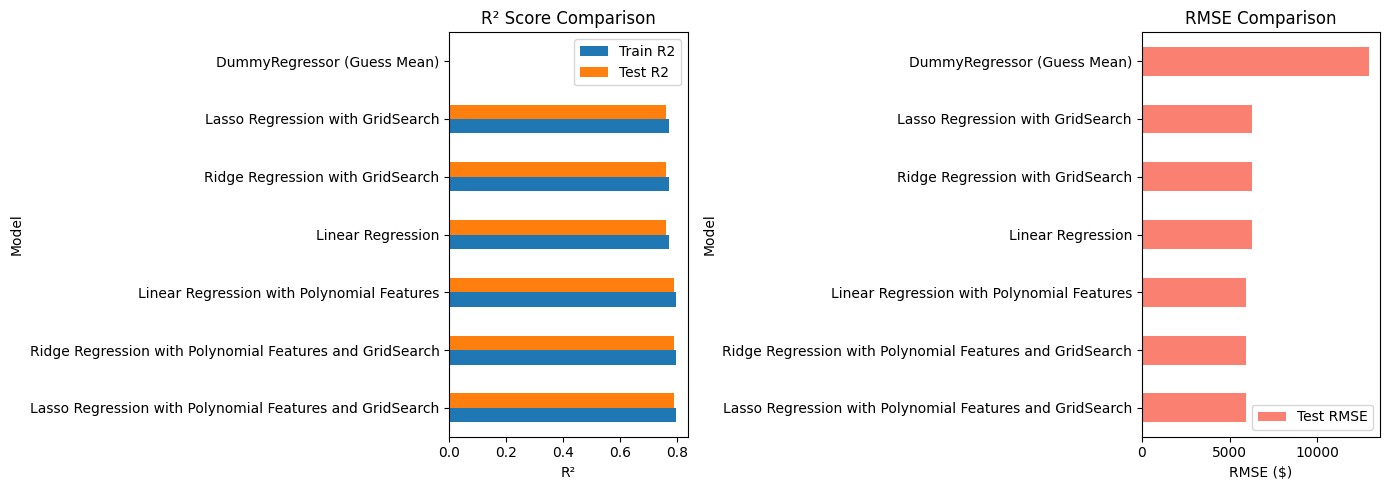

In [ ]:
#===============================================================
# Visualize Results from Models for comparison.
#===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparison
results_df.plot(kind='barh', x='Model', y=['Train R2', 'Test R2'], ax=axes[0])
axes[0].set_title('R² Score Comparison')
axes[0].set_xlabel('R²')
axes[0].legend(loc='upper right')

# RMSE comparison
results_df.plot(kind='barh', x='Model', y='Test RMSE', ax=axes[1], color='salmon')
axes[1].set_title('RMSE Comparison')
axes[1].set_xlabel('RMSE ($)')

plt.tight_layout()
plt.show()



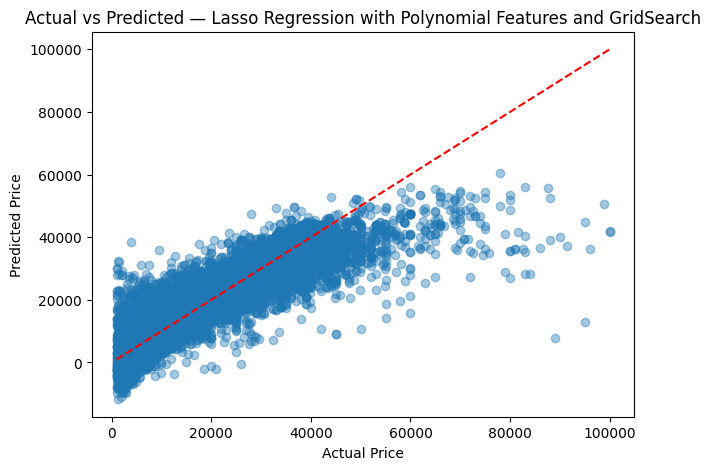

In [ ]:
#===============================================================
# Dive deeper into 'Best' Model Generated.
#===============================================================
best_model_name = results_df.iloc[0]['Model']
best_pipe = results_df.iloc[0]['Pipe']
y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted — {results_df.iloc[0]["Model"]}')
plt.show()

####Model Learnings
After building a total of 6 models, we can see alot of similarity between the models when they are categorized as models with and without Polynomial Features.  
The Models we created were Linear Regression, Ridge Regression with GridSearchCV and Lasso Regression with GridsearchCV.
We noticed that all models in the same groupings all performed very similarly, no matter what the regression model was. The biggest difference in performance improvement was indeed the introduction of Polynomial features which allowed our model to perform slightly better when compared to those without polynomial features.


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Next Steps from Models
After the initial modeling, we see that overall there is some non-linear behavior in the data that is captured when introducing polynomial features to the model. The difference between the Linear, Lasso and Ridge regression models with polynomial features tells us that regularization does little to improve the model, which can also be seen when comparing the models that do not use polynomial features. Overall the polynomial features themselves are helping improve the model.
The next steps I would draw from this is to see if increasing the polynomial features degree will lead to a better performing model or if the degree that was selected in the models generated above are infact the best performing.

In [78]:
#===============================================================
# Understand Metrics of Best Model Generated Above
#===============================================================
degree = lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['numerical'].named_steps['poly'].degree
print(f'Polynomial Degree: {degree}')
print(results_df[results_df['Model'] =='Linear Regression with Polynomial Features'].drop(columns ='Pipe').to_string(index=False))


Polynomial Degree: 3
                                     Model  CV RMSE  Train R2  Test MAE  Test RMSE  Test R2  R2 Gap
Linear Regression with Polynomial Features  5833.02    0.7967   4060.82    5920.77   0.7897   0.007


In [70]:
#===============================================================
# Expand Polynomial Degree Feature Size for Exploration.
#===============================================================
lr_poly_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('regressor', LinearRegression())
])

#GridSearch
trial_poly_lin_params = {'preprocessor__numerical__poly__degree': [2, 3, 4, 5, 6, 7, 8, 9]}
trial_lr_poly_grid = GridSearchCV(lr_poly_pipe, param_grid=trial_poly_lin_params,
                            cv=5, scoring='neg_mean_squared_error',
                            return_train_score=True)
#Fit model
trial_lr_poly_grid.fit(X_train, y_train)

#Eval Training Data
trial_pred = trial_lr_poly_grid.predict(X_train)
trial_lr_poly_train_r2 = r2_score(y_train, train_pred)

#Eval on Test Set
trial_lr_poly_pred = trial_lr_poly_grid.predict(X_test)
trial_lr_poly_test_mse = mean_squared_error(y_test, trial_lr_poly_pred)
trial_lr_poly_test_rmse = np.sqrt(trial_lr_poly_test_mse)
trial_lr_poly_test_mae = mean_absolute_error(y_test, trial_lr_poly_pred)
trial_lr_poly_test_r2 = r2_score(y_test, trial_lr_poly_pred)

degree = trial_lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['numerical'].named_steps['poly'].degree

print('Trial')
print('-'*50)
print(f'Polynomial Degree: {degree}')
print(f'Train R2: {trial_lr_poly_train_r2:.4f}')
print(f'Test MAE: {trial_lr_poly_test_mae:,.0f}')
print(f'Test RMSE: {trial_lr_poly_test_rmse:,.0f}')
print(f'Test R2: {trial_lr_poly_test_r2:.4f}')



Trial
--------------------------------------------------
Polynomial Degree: 9
Train R2: 0.7967
Test MAE: 3,995
Test RMSE: 5,835
Test R2: 0.7957


#### Trial Runs from Polynomial Features
I opted to do a trial run with higher degrees in polynomial features in an attempt to see if there would be a beneficial gain. We see from above that higher orders of degree do not improve our results drastically so we will stick to the original Model we built prior. This will be the one to evaluate further.  
I will also look to compare the learnings from the Linear Regression with Polynomial Features to the Simple Linear Regression model we produced

In [110]:
#===============================================================
# Better understand the Linear Regresion Model with Polynomial
# Features selected
#===============================================================

# Get all the feature names and coefficients out
degree = lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['numerical'].named_steps['poly'].degree
feature_names = list(lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['categorical'].get_feature_names_out(categorical_features)) + \
                list(lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['numerical'].get_feature_names_out(numeric_features))
test_feature_names =  list(lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['numerical'].get_feature_names_out(numeric_features)) + \
                 list(lr_poly_grid.best_estimator_.named_steps['preprocessor'].named_transformers_['categorical'].get_feature_names_out(categorical_features))
coefficients = lr_poly_grid.best_estimator_.named_steps['regressor'].coef_

# Create DataFrame with Features and Coefficients
lr_poly_df = pd.DataFrame({'Feature': test_feature_names, 'Coefficient': coefficients})
lr_poly_df["Abs_Coefficient"] = np.abs(lr_poly_df["Coefficient"])

# Create DataFrame Sorted by Biggest Impact Overall
abs_df = lr_poly_df.sort_values('Abs_Coefficient', ascending=False).drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Create DataFrame Sorted by Largest Positive Impact
desc_df = lr_poly_df.sort_values('Coefficient', ascending=False).drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Create DataFrame Sorted by Largest Negative Impact
asc_df = lr_poly_df.sort_values('Coefficient').drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Combine all
combined = pd.concat([abs_df, desc_df, asc_df], axis=1, keys = ['Overall','Positive','Negative'])

# Visualize Highest Influentual Features
print(f'Polynomial Degree: {degree}')
print(combined.head(25).to_string(index=False))


Polynomial Degree: 3
              Absolute                                Positive                             Negative             
               Feature  Coefficient                    Feature  Coefficient                 Feature  Coefficient
cylinders_12 cylinders 11364.611735     cylinders_12 cylinders 11364.611735   cylinders_3 cylinders -6096.869661
           fuel_diesel  9389.024048                fuel_diesel  9389.024048   cylinders_4 cylinders -5425.290193
cylinders_10 cylinders  6362.022083     cylinders_10 cylinders  6362.022083         cylinders_other -4654.065658
 cylinders_3 cylinders -6096.869661              condition_new  4131.217583           fuel_electric -4170.761115
 cylinders_4 cylinders -5425.290193                       year  3443.219900                odometer -3929.609913
       cylinders_other -4654.065658               type_offroad  3381.903211             vehicle_age -3443.219900
         fuel_electric -4170.761115         manufacturer_lexus  3354.787141

In [114]:
#===============================================================
# Better understand the Linear Regresion Model
#===============================================================
feature_names = (numeric_features) + list(lr_pipe.named_steps['preprocessor'].named_transformers_['categorical'].get_feature_names_out(categorical_features))
coefficients = lr_pipe.named_steps['regressor'].coef_

# Create DataFrame with Features and Coefficients
lr_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
lr_df["Abs_Coefficient"] = np.abs(lr_df["Coefficient"])

# Create DataFrame Sorted by Biggest Impact Overall
abs_df = lr_df.sort_values('Abs_Coefficient', ascending=False).drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Create DataFrame Sorted by Largest Positive Impact
desc_df = lr_df.sort_values('Coefficient', ascending=False).drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Create DataFrame Sorted by Largest Negative Impact
asc_df = lr_df.sort_values('Coefficient').drop(columns = 'Abs_Coefficient').reset_index(drop=True).copy()

# Combine all
lr_combined = pd.concat([abs_df, desc_df, asc_df], axis=1, keys = ['Overall','Positive','Negative'])

# Visualize Highest Influentual Features
print('Linear Regression')
print(lr_combined.head(25).to_string(index=False))

Linear Regression
              Absolute                                Positive                             Negative             
               Feature  Coefficient                    Feature  Coefficient                 Feature  Coefficient
cylinders_12 cylinders 11660.514662     cylinders_12 cylinders 11660.514662   cylinders_4 cylinders -5378.786679
           fuel_diesel  9475.215042                fuel_diesel  9475.215042         cylinders_other -5017.396762
cylinders_10 cylinders  5747.256261     cylinders_10 cylinders  5747.256261                odometer -4093.806966
         condition_new  5689.071272              condition_new  5689.071272   cylinders_5 cylinders -4060.393468
 cylinders_4 cylinders -5378.786679               type_offroad  4225.743717   cylinders_3 cylinders -4003.542506
       cylinders_other -5017.396762         manufacturer_lexus  3397.717572           fuel_electric -3341.590992
          type_offroad  4225.743717        manufacturer_toyota  3275.677131   

### Model Conclusions
After doing a thorough analysis of the models we generated above, we can see that the learnings we gained between Linear Regression with and without Polynomial Features are pretty much identical. The simple linear regression model is suffice for the data at hand, as the impact in adding polynomial only results in a 2% increase explanation of the variance of the data. Implementing Ridge and Lasso Regression also does not provide a substantial gain in understanding as well.

We see that the biggest non-manufacturer features that impact price that can be generalized are engine size, vehicle type, odometer, year, title status and fuel type.    

The models and coefficients are telling a story about used vehicle pricing. What was learned from the data we have on hand provides some insight on what we can expect to impact used vehicle prices, however this comes with limitations. From the data, our model learns how each feature within affects our target variable and we can expect this to be altered with a data set that holds a different distribution. While with this model we find many distinct features that hold positive impacts on pricing, the overall understanding is from the features that hold true for vehicles in general. Vehicle age, mileage, condition and title status are features that will hold the biggest impact overall on the market of used vehicles.






### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

# Report: Main Drivers for Used Car Prices
## Prepared for Used Car Delearships Seeking Inventory Optimization


---

### Summary
We were able to identify the main features that influence the prices of used vehicles on the market. Utilizing over 100,000 listings to train multiple regression models, the top findings are summarized below.

#### Findings.


1.   **Vehicle Age**

*   Findings: Vehicle age inversely impacts pricing. The older the vehilcle, the lower the price.


2.   **Odometer**


*   Findings: Higher mileage also affects vehicle pricing, as odometer increases pricing will decrease due to the wear and tear it brings.

3.   **Condition**

*   Findings: The better the condition of the vehicle, the higher the price tag.  

4.   **Vehicle Type**

*   Findings: Specific purpose vehicles come with a higher price tag, examples include off-road, trucks, and convertibles.

5.   **Title**

*   Findings: Clean and lien titles provide more value to the vehicles.

6.   **Manufacturer**

*   Findings: Each manufacturer brings forth their own comfort, reliablity and style. Top brands include Lexus, Toyota, Mercedez-Benz.

7.   **Fuel Type**

*   Findings: Diesel vehicles are higher valued in comparison to other fuel types. The longevity they provide for consumers is well known and is reflected on the pricing.

8.   **Engine Size**

*   Findings: The data found that bigger engine sized vehicles also bring forward a higher price tag for used vehicles.

9.   **Drive Type**

*   Findings: Pricing indicates that RWD/4WD vehicles hold higher price points in comparison to FWD vehicles.

10.  **Other Findings**

*   Paint Color is the least significant feature of a used vehicle.
*   Electric and Hybrids hold a negative impact on price from our models.


# Conclusions and Next Steps
After going through the models and deriving key features for used vehicles in terms of pricing, used car dealerships should focus on establishing an overall inventory of vehicles that are younger in age, hold lower mileage in good to new condition and with clean or lien titles. These would be the biggest areas of focus on for vehicles that bring forth a better price point overall.   
Within these, there would be room for dealerships to invest some capital in vehicles that are in the good or excellent condition to improve the quality of the vehicle and drive the price forward for better profit margin.  

The second area to focus on would be to hold an inventory specific to the specialty vehicle market. Trucks, offroad, and convertibles are some of the higher valued vehicles on the market. This would in turn bring in the individuals that are looking for the non-standard vehicles most individuals utilize in their day to day. Naturally finding some diesel vehicles will allow for a wide array of possibilities for bringing in potential clients.

From this, there are a few things to consider in terms of next steps.


1.   Removing the 'other' classification would provide better understanding. Better data should be collected to further understand vehicle features.
2.   Price analysis for vehicles within the region the dealership is located.Every part of the country holds different needs for vehicles.
3.   Understanding vehicle sales within the region of the used car delearship would be crucial for optimizing inventory for the market they reside in. Vehicle pricing is one factor, but actual vehicle purchases will provide a better picture of what will actually move out of the lot.

